# **Section 1: Let's create an artificial neuron**

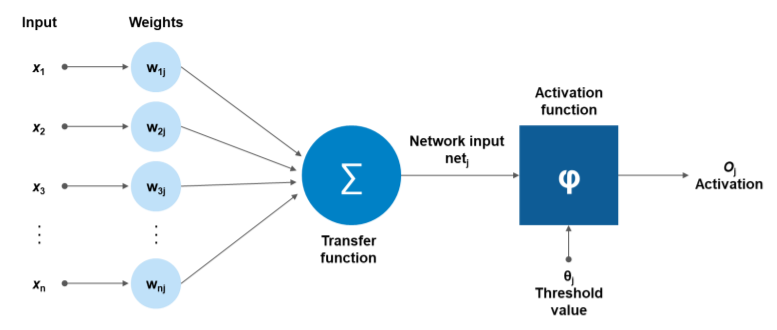

### Imports

In [ ]:
import torch

## **Section 1.1: Simple neuron**

### Input, weight and bias

In [ ]:
x = torch.tensor([[1., 2., 0., 4., 1.],
                  [0., 1., 1., 1., 1.],
                  [2., 3., 0., 1., 4.]])

w = torch.tensor([1., 0.5, 1., -1., -0.5])

b = torch.tensor(1.)

### Linear activation function

In [ ]:
def linear(x):
  return x

### Step activation function

In [ ]:
def step(x):
  if x > 0:
    y = torch.tensor(1.)
  elif x < 0:
    y = torch.tensor(0.)
  else:
    y = torch.tensor(0.5)
  return y

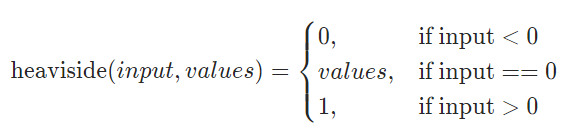

In [ ]:
torch.heaviside(torch.tensor(0.), torch.tensor(5.5))

tensor(5.5000)

In [ ]:
def step(x):
   if x > 0 :
        y = torch.tensor(1.)
   elif x <0 :
        y = torch.tensor(0.)
   else :
        y= torch.tensor(0.5)
   return y



### Neuron function

In [ ]:
def neuron(x, w, b, af):
  z = 0
  for xi, wi in zip(x, w):
    z += xi * wi
  z += b
  y = af(z)
  return y

### Test

In [ ]:
neuron(x[0], w, b, linear)

tensor(-1.5000)

In [ ]:
neuron(x[0], w, b, step)

tensor(0.)

## **Section 1.2: Vectorization** 🕶

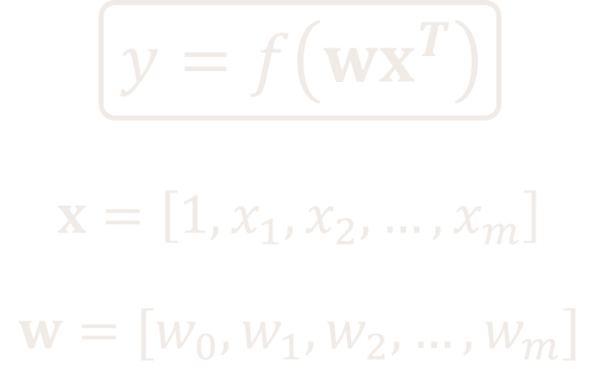

In [ ]:
def neuron(x, w, b, af):
  y = af(x @ w + b)
  return y

In [ ]:
neuron(x[0], w, b, linear)

tensor(-1.5000)

In [ ]:
neuron(x[0], w, b, step)

tensor(0.)

## **Section 1.3: Class Neuron 🔥**

In [ ]:
class Neuron:
  def __init__(self, m, af):
      self.w = torch.randn(m)
      self.b = torch.randn(1)
      self.af = af
  def __call__(self, x):
      y = self.af(self.w @ x + self.b)
      return y

In [ ]:
neuron2 = Neuron(5, linear)

In [ ]:
neuron2(x[0])

tensor([-3.6137])

In [ ]:
inputs = torch.tensor([[1., 2., 0., 4., 1.],
                       [0., 1., 1., 1., 1.],
                       [2., 3., 0., 1., 4.]])



# **Section 2: Loss functions**

## Imports

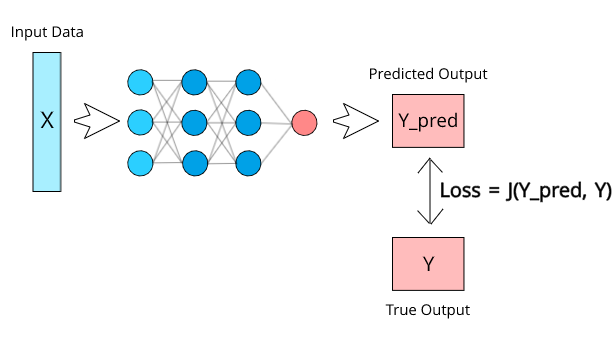

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

## Prediction and target

In [ ]:
yp = torch.tensor([-0.39, -0.47,  0.61, -0.75,  0.31, -0.54,  0.61, -2.83, 1.24,  0.10])

yt = torch.tensor([-0.39,  1.00,  0.51, -0.85,  0.31, -0.04,  1.01, -0.55, 1.24,  0.10])

## Mean Squared Error (MSE)
\begin{align}
MSE &= \frac{1}{n} \sum_{i=1}^n (y_{p_i}-y_{t_i})^2
\end{align}

### From scratch

In [ ]:
torch.mean((yp - yt)**2)

tensor(0.7789)

### MSE class in pytorch

In [ ]:
mse = nn.MSELoss()
mse(yp, yt)

tensor(0.7789)

### MSE function in pytorch

In [ ]:
F.mse_loss(yp, yt)

tensor(0.7789)

## Mean Absolute Error (MAE)
\begin{align}
MAE &= \frac{1}{n} \sum_{i=1}^n |y_{p_i}-y_{t_i}|
\end{align}

### From scratch

In [ ]:
mae = torch.mean(yt-yp)

In [ ]:
mae

tensor(0.4450)

### MAE class in pytorch

In [ ]:
mae = nn.L1Loss()
mae(yp, yt)

tensor(0.4850)

### MAE function in pytorch

In [ ]:
F.l1_loss(yp, yt)

tensor(0.4850)

## Connect neuron to loss funtion! ⚡


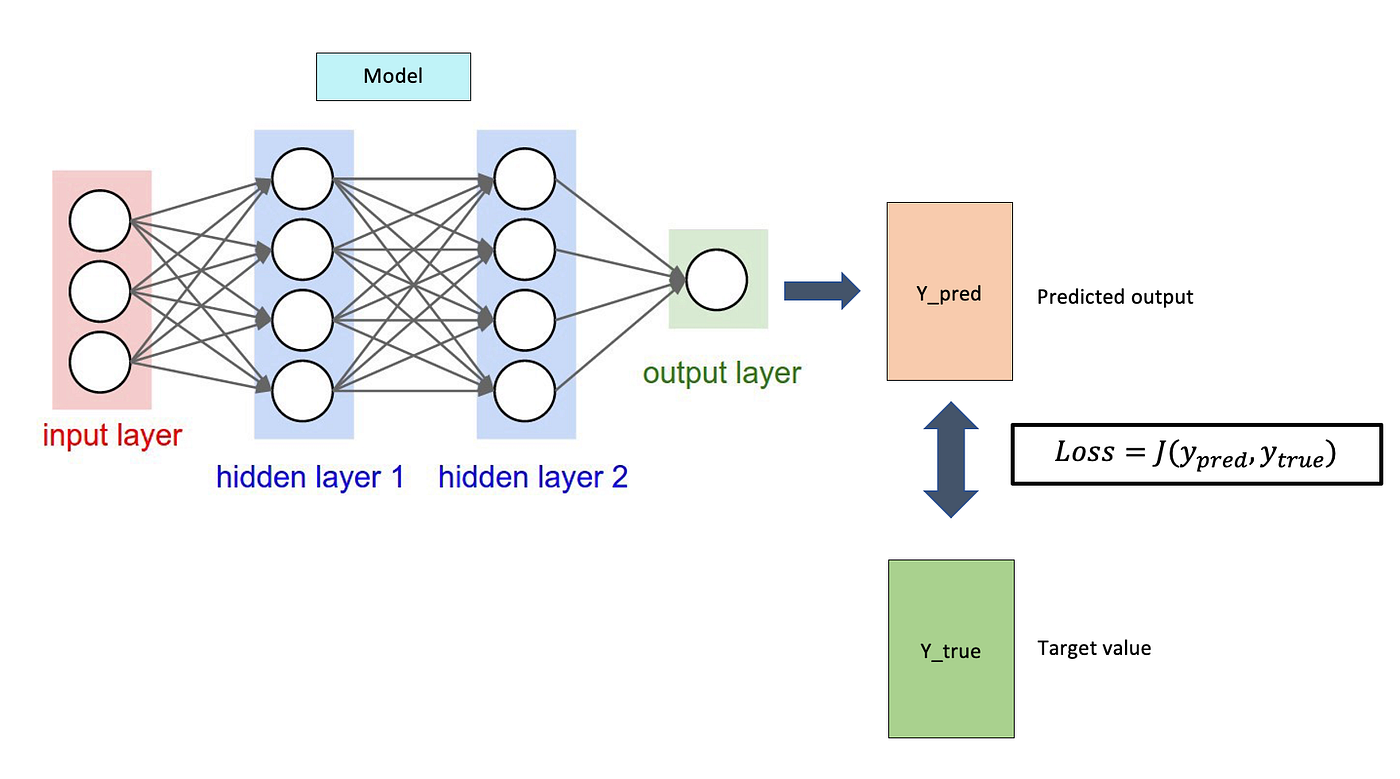

### From Section 1

In [ ]:
class Neuron:
  def __init__(self, m, af):
      self.w = torch.randn(m)
      self.b = torch.randn(1)
      self.af = af

  def __call__(self, x):
    if self.af == 'linear':
      y = self.linear(self.w @ x + self.b)
    elif self.af == 'step':
      y = self.step(self.w @ x + self.b)
    return y

  def linear(self, x):
    return x

  def step(self, x):
    return torch.heaviside(x,torch.tensor(1.0))


In [ ]:
neuron = Neuron(5, 'step')

### Input & target

In [ ]:
x = torch.tensor([[1., 2., 0., 4., 1.],
                  [0., 1., 1., 1., 1.],
                  [2., 3., 0., 1., 4.]])

yt = torch.tensor([1., 2., 0.])

In [ ]:
x.dtype

torch.float32

### Now give output of the neuron to the loss funtion

In [ ]:
yp = neuron(x[0])

e = F.mse_loss(yp, yt[[0]])
print(e)

tensor(0.)


In [ ]:
yt[0:1]

tensor([1.])

In [ ]:
yp = neuron(x)

e = ...
print(e)

# **Section 3: Gradient descent**

## Imports

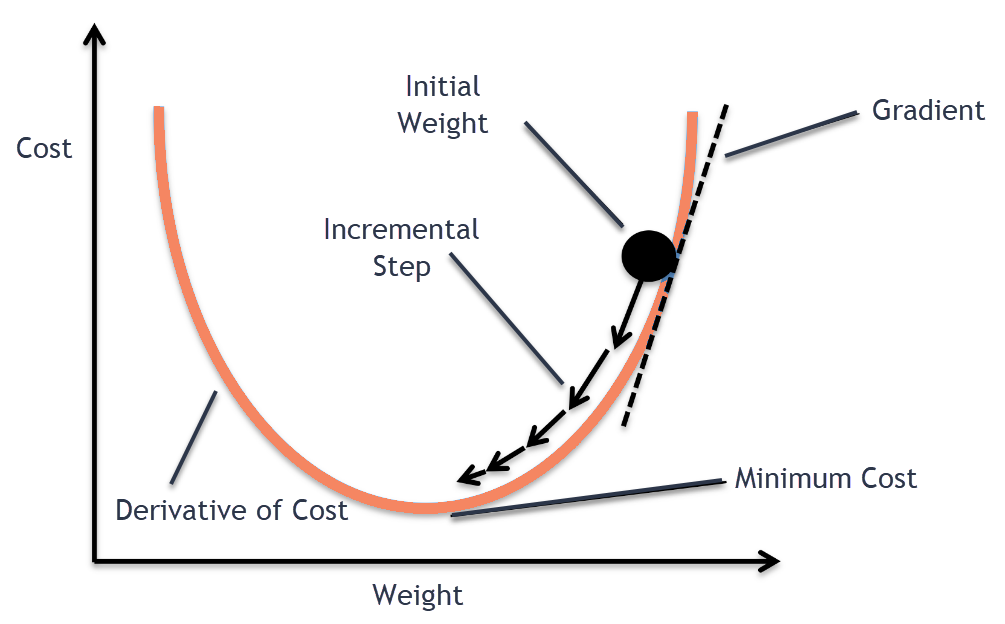

In [ ]:
import torch

## Visualization

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [ ]:
def plot(x, func):
  plt.figure(figsize=(8, 6))
  plt.plot(x, func(x), linewidth=3)
  plt.xlabel('x', fontsize=15)
  plt.ylabel('f(x)', fontsize=15)
  plt.show()

In [ ]:
def animate(x, func, gradfunc, xi, eta, N):
  if gradfunc is None:
    gradfunc = func
  xi_hist = []
  xi_hist.append(xi.clone())
  for iter in range(N):
    xi = gradient_descent(gradfunc, xi, eta, 1)
    xi_hist.append(xi.clone())
  xi_hist = torch.tensor(xi_hist)
  fxi_hist = func(xi_hist)
  # plot animation
  fig = plt.figure(figsize=(8, 6))
  ax = fig.add_subplot(1, 1, 1)
  def plot_animate(i):
    ax.clear()
    ax.plot(x, func(x), linewidth=3)
    ax.plot(xi_hist[0:i], fxi_hist[0:i], color='black', linewidth=4)
    ax.plot(xi_hist[0], fxi_hist[0], 'r*', markersize=15)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
  ani = animation.FuncAnimation(fig, plot_animate,
                                frames=len(xi_hist),
                                interval=120,
                                repeat=False)
  plt.close()
  return HTML(ani.to_html5_video())

In [ ]:
from IPython.display import HTML

def animate(x, func, gradfunc, xi, eta, N):
    if gradfunc is None:
        gradfunc = func

    xi_hist = [xi.clone()]
    for _ in range(N):
        xi = gradient_descent(gradfunc, xi, eta, 1)
        xi_hist.append(xi.clone())

    xi_hist = torch.tensor(xi_hist)
    fxi_hist = func(xi_hist)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1, 1, 1)

    def plot_animate(i):
        ax.clear()
        ax.plot(x, func(x), linewidth=3)
        ax.plot(xi_hist[:i], fxi_hist[:i], color='black', linewidth=4)
        ax.plot(xi_hist[0], fxi_hist[0], 'r*', markersize=15)
        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')

    ani = animation.FuncAnimation(fig, plot_animate,
                                  frames=len(xi_hist),
                                  interval=120,
                                  repeat=False)
    plt.close(fig)

    # Use JS animation (no ffmpeg needed)
    return HTML(ani.to_jshtml())


## Find the minimum of $ f(x) = x^{2} $

### Implement $ f $

In [ ]:
def funcx2(x):
  return x**2

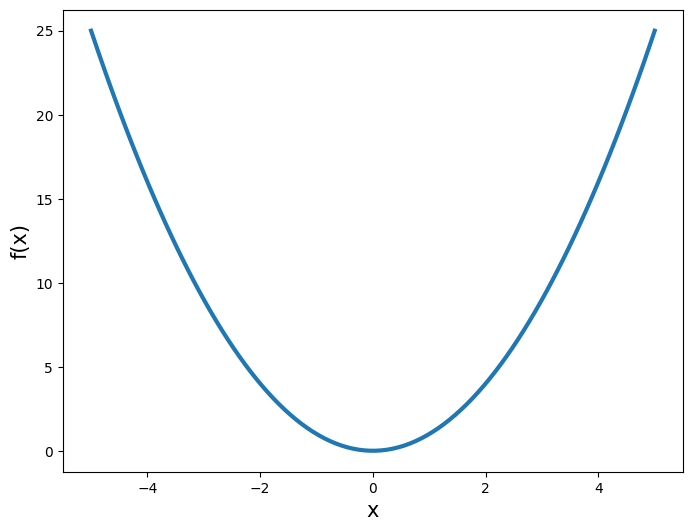

In [ ]:
# is short for “linear space”. It’s a function (in PyTorch) that generates a sequence of numbers evenly spaced over a specified interval
x = torch.linspace(-5, 5, 100)
plot(x, funcx2)

### Implement gradient function

In [ ]:
def gradfx2(x):
  return 2*x

### Implement gradient descent

In [ ]:
def gradient_descent(gradfunc, xi, eta, N):
  for iter in range(N):
    xi -= eta * gradfunc(xi)
  return xi

In [ ]:
N = 50
eta = 0.9
xi = torch.tensor(-4.)
gradient_descent(gradfx2, xi, eta, N)

tensor(-5.7090e-05)

### Animation

In [ ]:
xi = torch.tensor(-4.)
eta = 0.3
N = 80

animate(x, funcx2, gradfx2, xi, eta, N)

## Find the minimum
$ f(x) = 0.125x^4-0.1875x^3-0.75x^2+0.5x $

$ f^{'}(x) = 0.5x^3-0.5625x^2-1.5x+0.5$

$ x \in [-2.5, 3.3] $

### Implement $ f $ and its gradient

In [ ]:
def funcx4(x):
  return 0.125*x**4 - 0.1875*x**3 - 0.75*x**2 + 0.5*x

In [ ]:
def gradfx4(x):
  return 0.5*x**3 - 0.5625*x**2 - 1.5*x + 0.5

### Animation

In [ ]:
x = torch.linspace(-2.5, 3.3, 100)
xi = torch.tensor(1.)
eta = 0.3
N = 30

animate(x, funcx4, gradfx4, xi, eta, N)

## Find the minimum
$ f(x) = log( 1 + |x| ) ^ {2 + sin(x)} $

$ x \in [-10.5, 10.5] $

### Implement $ f $

In [ ]:
def funclog(x):
  return torch.log(1 + torch.abs(x))**(2 + torch.sin(x))

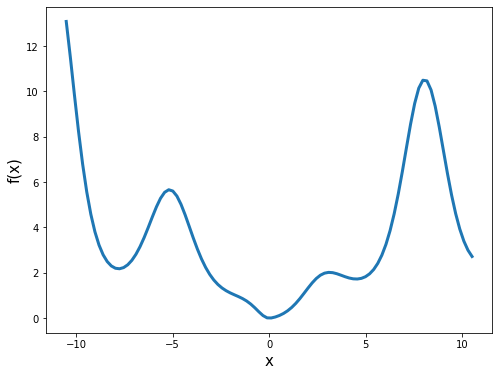

In [ ]:
x = torch.linspace(-10.5, 10.5, 100)
plot(x, funclog)

### Implement gradient function 😨

In [ ]:
# ???!!!

### Animatation

# **Section 4: Autograd**

## Imports

In [ ]:
import torch

## Visualization

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [ ]:
def plot(x, func):
  plt.figure(figsize=(8, 6))
  plt.plot(x, func(x), linewidth=3)
  plt.xlabel('x', fontsize=15)
  plt.ylabel('f(x)', fontsize=15)
  plt.show()

In [ ]:
def animate(x, func, gradfunc, xi, eta, N):
  if gradfunc is None:
    gradfunc = func
  xi_hist = []
  xi_hist.append(xi.clone())
  for iter in range(N):
    xi = gradient_descent(gradfunc, xi, eta, 1)
    xi_hist.append(xi.clone())
  xi_hist = torch.tensor(xi_hist)
  fxi_hist = func(xi_hist)
  # plot animation
  fig = plt.figure(figsize=(8, 6))
  ax = fig.add_subplot(1, 1, 1)
  def plot_animate(i):
    ax.clear()
    ax.plot(x, func(x), linewidth=3)
    ax.plot(xi_hist[0:i], fxi_hist[0:i], color='black', linewidth=4)
    ax.plot(xi_hist[0], fxi_hist[0], 'r*', markersize=15)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
  ani = animation.FuncAnimation(fig, plot_animate,
                                frames=len(xi_hist),
                                interval=120,
                                repeat=False)
  plt.close()
  return HTML(ani.to_html5_video())

## Derivative of $ f(x) = x^{2} $ with autograd pytorch `backward`

In [ ]:
x = torch.tensor(3., requires_grad=True)
y = x**2
print(y)
y.backward()
x.grad

tensor(9., grad_fn=<PowBackward0>)


tensor(6.)

## Find the minimum of $ f(x) = x^{2} $ with pytorch autograd `backward`

### Implement $ f $

In [ ]:
def funcx2(x):
  return x**2

### Implement gradient descent

In [ ]:
def gradient_descent(func, xi, eta, N):
  for iter in range(N):
    func(xi).backward()
    xi.data -= eta * xi.grad
    xi.grad.zero_()
  return xi

In [ ]:
xi = torch.tensor(3., requires_grad=True)
eta = 0.1
N = 50
gradient_descent(funcx2, xi, eta, N)

tensor(4.2817e-05, requires_grad=True)

### Animation

In [ ]:
xi = torch.tensor(-4., requires_grad=True)
eta = 0.1
N = 50
x = torch.linspace(-4., 4, 100)

animate(x, funcx2, None, xi, eta, N)

## Find the minimum
$ f(x) = log( 1 + |x| ) ^ {2 + sin(x)} $

$ x \in [-10.5, 10.5] $

### Implement $ f $

In [ ]:
def funclog(x):
  return torch.log(1 + torch.abs(x))**(2 + torch.sin(x))

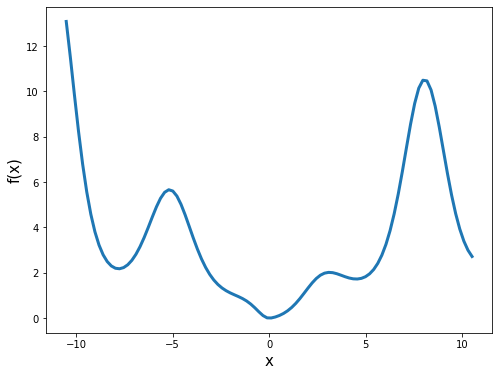

In [ ]:
x = torch.linspace(-10.5, 10.5, 100)
plot(x, funclog)

### Animatation 😎

In [ ]:
xi = torch.tensor(-4., requires_grad=True)
eta = 0.3
N = 50

animate(x, funclog, None, xi, eta, N)

## Find the minimum
$ f(x) = (x^2 - 1)^3 $

$ x \in [-1.5, 1.5] $

### Implement $ f $

In [ ]:
def funcx3(x):
  return ...

### Visualize $ f $

In [ ]:
x = torch.linspace(-1.5, 1.5, 100)

plot(x, funcx3)

### Animatation

In [ ]:
xi = ...
eta = ...
N = ...

animate(x, ..., ..., ..., eta, N)

## 3D

In [ ]:
!pip install matplotlib==2.2.3

### Imports

In [ ]:
import torch

### Visualization

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
def plot3d(x, y, func):
  x, y = torch.meshgrid(x, y)
  z = func(x, y)
  fig = plt.figure(figsize=(15, 10))
  ax = plt.axes(projection='3d')
  ax.plot_surface(x.numpy(), y.numpy(), z.numpy(), cmap='viridis')
  plt.show()

In [ ]:
def animate3d(x, y, func, gradfunc, xi, yi, eta, N):
  x, y = torch.meshgrid(x, y)
  if gradfunc is None:
    gradfunc = func
  xi_hist = []
  yi_hist = []
  xi_hist.append(xi.clone())
  yi_hist.append(yi.clone())
  for iter in range(N):
    xi, yi = gradient_descent3d(gradfunc, xi, yi, eta, 1)
    xi_hist.append(xi.clone())
    yi_hist.append(yi.clone())
  xi_hist = torch.tensor(xi_hist, requires_grad=False)
  yi_hist = torch.tensor(yi_hist, requires_grad=False)
  fi_hist = func(xi_hist, yi_hist)
  # plot animation
  fig = plt.figure(figsize=(15, 10))
  ax = plt.axes(projection='3d')
  def plot_animate(i):
    ax.clear()
    ax.plot_surface(x.numpy(), y.numpy(), func(x, y).numpy(), cmap='viridis')
    ax.plot(xi_hist[0:i].tolist(), yi_hist[0:i].tolist(), fi_hist[0:i].tolist(),
            color='black', linewidth=4)
    ax.plot([xi_hist[0]], [yi_hist[0]], [fi_hist[0]],
            'r*', markersize=15)
  ani = animation.FuncAnimation(fig, plot_animate,
                                frames=len(xi_hist),
                                interval=60,
                                repeat=False)
  plt.close()
  return HTML(ani.to_html5_video())

### Find the minimum
$ f(x,y) = xe^{-x^2-y^2}+0.05(x^2+y^2) $

$ x,y \in [-2, 2] $

Implement $ f $

In [ ]:
def func3d(x, y):
  return x * torch.exp(-x**2 - y**2) + 0.05 * (x**2 + y**2)

Visualize $ f $

/usr/local/lib/python3.7/dist-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


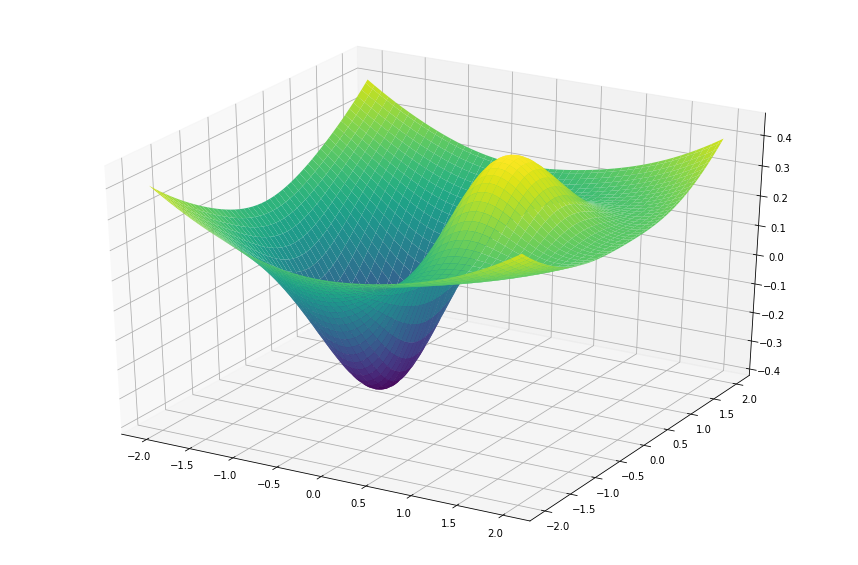

In [ ]:
x = torch.linspace(-2, 2, 100)
y = torch.linspace(-2, 2, 100)

plot3d(x, y, func3d)

Gradient descent

In [ ]:
def gradient_descent3d(func, xi, yi, eta, N):
  for iter in range(N):
    func(xi, yi).backward()
    xi.data -= eta * xi.grad
    yi.data -= eta * yi.grad
    xi.grad.zero_()
    yi.grad.zero_()
  return xi, yi

Animate

In [ ]:
xi = torch.tensor(-2., requires_grad=True)
yi = torch.tensor(2., requires_grad=True)
eta = 0.1
N = 100

animate3d(x, y, func3d, None, xi, yi, eta, N)

### Find the minimum
$ f(x,y) = x^2-y^2 $

$ x,y \in [-2, 2] $

Implement $ f $

In [ ]:
def func3d(x, y):
  return ...

Visualize $ f $

Animate

In [ ]:
animate3d(...)

## Now connect grad function to the train block diagram! ⚡

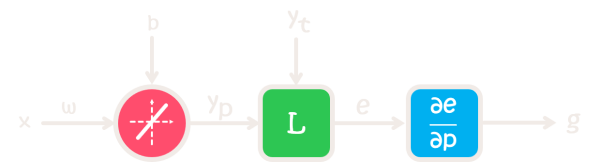

### Imports

In [ ]:
import torch
import torch.nn.functional as F

### Input & target

In [ ]:
x = torch.tensor([[1., 2., 0., 4., 1.],
                  [0., 1., 1., 1., 1.],
                  [2., 3., 0., 1., 4.]])

yt = torch.tensor([1., 2., 0.])

### From Section 1

In [ ]:
class Neuron:
  def __init__(self, m, af):
      self.w = torch.randn(m, requires_grad=True)
      self.b = torch.randn(1, requires_grad=True)
      self.af = af

  def __call__(self, x):
    if self.af == 'linear':
      y = self.linear(self.w @ x + self.b)
    elif self.af == 'step':
      y = self.step(self.w @ x + self.b)
    return y

  def linear(self, x):
    return x

  def step(self, x):
    pass

In [ ]:
neuron = Neuron(5, 'linear')

In [ ]:
neuron.w

tensor([-0.6001, -1.6776, -1.0444,  0.8737, -0.4117], requires_grad=True)

In [ ]:
yp = neuron(x[0])

### From Section 2

In [ ]:
e = F.mse_loss(yp, yt[[0]])

In [ ]:
e

tensor(1.3288, grad_fn=<MseLossBackward0>)

### Now calculate the gradient of `(w,b)`

In [ ]:
e.backward()

In [ ]:
neuron.w.grad

tensor([-2.3055, -4.6110, -0.0000, -9.2220, -2.3055])

In [ ]:
neuron.b.grad

tensor([-2.3055])

# **Section 5: Optimizer**

## Imports

In [ ]:
import torch
from torch import optim

## Find the minimum of $ f(x) = x^{2} $

### Implement $ f $

In [ ]:
def funcx2(x):
  return x**2

### Implement gradient descent

In [ ]:
xi = torch.tensor(-3., requires_grad=True)

In [ ]:
params = [xi]
eta = 0.1
optimizer = optim.SGD(params, eta)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    foreach: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [ ]:
N = 50

for iter in range(N):
  funcx2(xi).backward()
  optimizer.step()
  optimizer.zero_grad()

In [ ]:
xi

tensor(-4.2817e-05, requires_grad=True)

## Find the minimum
$ f(x,y) = xe^{-x^2-y^2}+0.05(x^2+y^2) $

$ x,y \in [-2, 2] $

### Implement $ f $

In [ ]:
def func3d(x, y):
  return x * torch.exp(-x**2-y**2) + 0.05*(x**2+y**2)

### Gradient descent

In [ ]:
xi = torch.tensor(-1.8, requires_grad=True)
yi = torch.tensor(1.8, requires_grad=True)

In [ ]:
params = [xi, yi]
eta = 0.1
optimizer = optim.SGD(params, eta)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    foreach: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [ ]:
N = 100

for iter in range(N):
  func3d(xi, yi).backward()
  optimizer.step()
  optimizer.zero_grad()

In [ ]:
xi, yi

(tensor(-0.6691, requires_grad=True), tensor(0.0026, requires_grad=True))

In [ ]:
optimizer.param_groups

[{'dampening': 0,
  'foreach': None,
  'lr': 0.1,
  'maximize': False,
  'momentum': 0,
  'nesterov': False,
  'params': [tensor(-0.6691, requires_grad=True),
   tensor(0.0026, requires_grad=True)],
  'weight_decay': 0}]

## Now connect optimzier to the train block diagram! ⚡

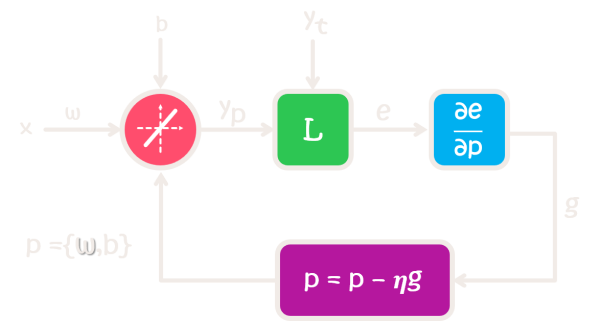

### Imports

In [ ]:
import torch
import torch.nn.functional as F
from torch import optim

### Input & target

In [ ]:
x = torch.tensor([[1., 2., 0., 4., 1.],
                  [0., 1., 1., 1., 1.],
                  [2., 3., 0., 1., 4.]])

yt = torch.tensor([1., 2., 0.])

### From Section 1

In [ ]:
class Neuron:
  def __init__(self, m, af):
      self.w = torch.randn(m, requires_grad=True)
      self.b = torch.randn(1, requires_grad=True)
      self.af = af

  def __call__(self, x):
    if self.af == 'linear':
      y = self.linear(self.w @ x + self.b)
    elif self.af == 'step':
      y = self.step(self.w @ x + self.b)
    return y

  def linear(self, x):
    return x

  def step(self, x):
    pass

In [ ]:
neuron = Neuron(5, 'linear')

In [ ]:
yp = neuron(x[0])

### From Section 2

In [ ]:
e = F.mse_loss(yp, yt[[0]])
e

tensor(7.8715, grad_fn=<MseLossBackward0>)

### From Section 4

In [ ]:
e.backward()

In [ ]:
neuron.w.grad, neuron.b.grad

(tensor([ 5.6113, 11.2225,  0.0000, 22.4450,  5.6113]), tensor([5.6113]))

### Now add optimizer!

In [ ]:
params = [neuron.w, neuron.b]
eta = 0.1
optimizer = optim.SGD(params, eta)

In [ ]:
optimizer.step()
optimizer.zero_grad()

### Final

In [ ]:
for iter in range(50):
  yp = neuron(x[0])
  e = F.mse_loss(yp, yt)
  e.backward()
  optimizer.step()
  optimizer.zero_grad()

# **Section 6: Create the First Neural Network**

In [ ]:
import torch
from torch import nn

## Example 1: single neuron

In [ ]:
fc = nn.Linear(in_features=5, out_features=1)


In [ ]:
fc.weight

Parameter containing:
tensor([[-0.4280, -0.0293, -0.1574,  0.3204, -0.0061]], requires_grad=True)

In [ ]:
fc.bias

Parameter containing:
tensor([0.3976], requires_grad=True)

In [ ]:
fc.weight

Parameter containing:
tensor([[-0.4280, -0.0293, -0.1574,  0.3204, -0.0061]], requires_grad=True)

In [ ]:
x = torch.randn(100, 5)

In [ ]:
fc(x)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x1 and 5x1)

## Example 2: fully connected layer (perceptron layer)

In [ ]:
fc = nn.Linear(4, 5, bias=False)

In [ ]:
x = torch.tensor([[94., 69, 33, 42],
                  [66, 72, 21, 99],
                  [98, 59, 54, 38],
                  [60, 86, 37, 21],
                  [29, 65, 41, 78],
                  [56,  5, 99, 11]])  #shape[6,4]

In [ ]:
fc(x).shape

torch.Size([6, 5])

In [ ]:
fc.bias

## Example 3: MLP

In [ ]:
x = torch.tensor([[  6.,   9,   5],
                  [ -1,  -10,   5],
                  [  2,   -1,  -9],
                  [  3,    1,   1]]) #[n_sample=4, n_feature=3]

In [ ]:
fc1 = nn.Linear(3, 8)
fc2 = nn.Linear(8, 5, bias=False)

In [ ]:
fc2(fc1(x))

tensor([[ 1.7000,  2.2613,  0.9412, -2.4977,  2.0123],
        [-1.9784, -2.0589,  5.5536, -1.8673, -0.2195],
        [ 1.2344,  0.4588, -4.4247,  2.6525, -1.0731],
        [ 0.5800,  0.5874,  0.6649, -0.8607,  0.5304]], grad_fn=<MmBackward0>)

In [ ]:
mlp = nn.Sequential(nn.Linear(3, 8),
                    nn.Linear(8, 5))
mlp

Sequential(
  (0): Linear(in_features=3, out_features=8, bias=True)
  (1): Linear(in_features=8, out_features=5, bias=True)
)

In [ ]:
mlp(x)

tensor([[-1.5005,  2.2325, -3.4555,  4.4793, -2.4771],
        [-4.5597, -2.4378, -0.4443, -3.3633, -0.3727],
        [ 3.0363,  1.0571,  1.1271, -1.1396,  2.2514],
        [-1.0363,  0.6397, -1.3420,  0.7543, -0.5638]],
       grad_fn=<AddmmBackward0>)

In [ ]:
mlp[1].weight

Parameter containing:
tensor([[-0.2681,  0.0677, -0.2137,  0.2371, -0.2403, -0.2468, -0.0392,  0.2903],
        [-0.3247,  0.0268, -0.3125,  0.0164,  0.2917,  0.2075,  0.3299,  0.0539],
        [ 0.2214, -0.3127,  0.3488, -0.0116, -0.2239,  0.0008,  0.1286,  0.2801],
        [ 0.1322,  0.1329,  0.2262,  0.2151,  0.3006,  0.0038, -0.2698,  0.2222],
        [-0.2386, -0.1789,  0.1049,  0.1151, -0.2460,  0.2359,  0.2481,  0.1448]],
       requires_grad=True)

# **Final Section: Train Neural Network**

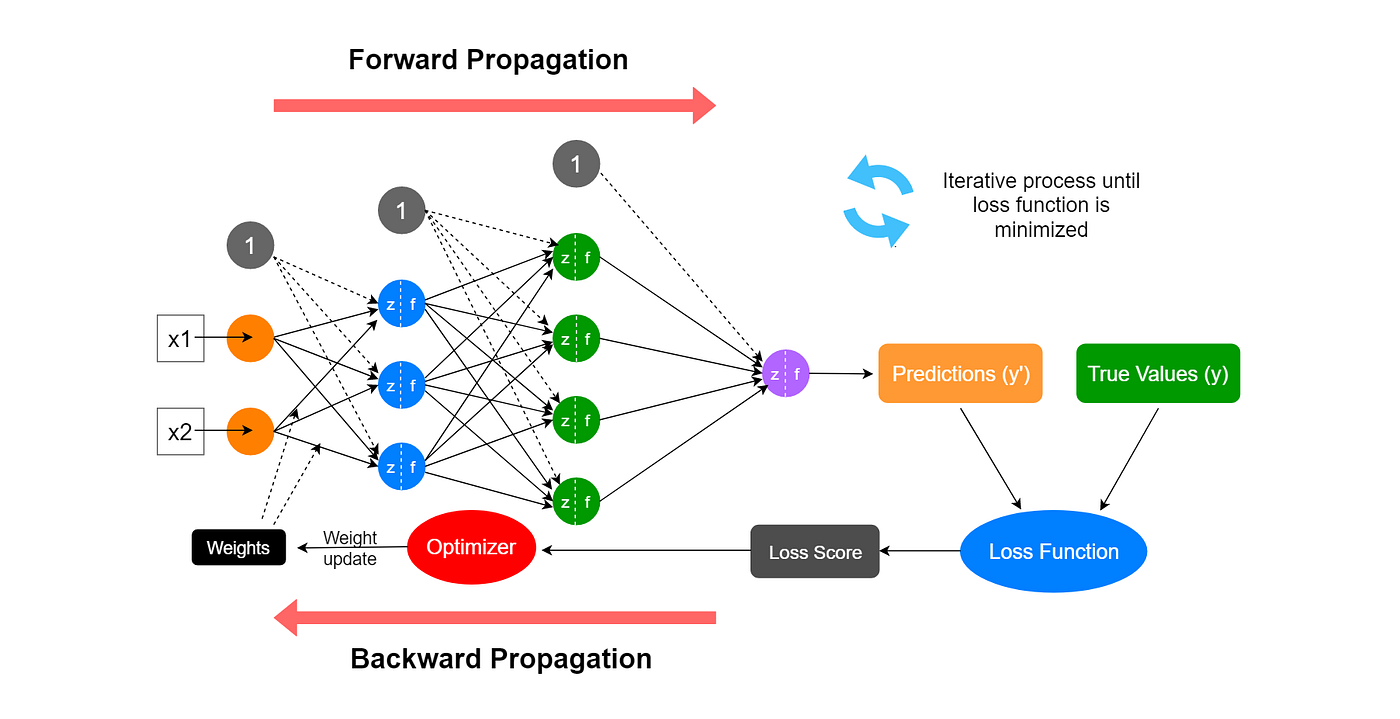

## Imports

In [ ]:
import torch
from torch import nn
from torch import optim

import pandas as pd
import matplotlib.pyplot as plt
import zipfile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1: load data

In [ ]:
!cp  /content/drive/MyDrive/Demis_learning_Materials/train.csv .
!cp  /content/drive/MyDrive/Demis_learning_Materials/test.csv .

'cp' is not recognized as an internal or external command,
operable program or batch file.
'cp' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
zip_path = r"C:\Teaching_DL\datasets.zip"

extract_to = r"C:\Teaching_DL"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)


In [ ]:
train_path = (r"C:\Teaching_DL\data\train.csv")
test_path  = (r"C:\Teaching_DL\data\test.csv")

### Train

In [ ]:
df = pd.read_csv(train_path)
df.head()

,Unnamed: 0,x,y
0,0,0.771270,2.474538
1,1,0.063558,1.192772
2,2,0.863103,2.912784
3,3,0.025419,1.078507
4,4,0.731994,2.473164


In [ ]:
x_train.shape

In [ ]:
x_train = torch.tensor(df['x'].values , dtype = torch.float32).unsqueeze(1)
y_train = torch.tensor(df['y'].values , dtype = torch.float32)

In [ ]:
x_train

tensor([[0.7713],
        [0.0636],
        [0.8631],
        [0.0254],
        [0.7320],
        [0.0740],
        [0.1987],
        [0.3110],
        [0.4722],
        [0.9696],
        [0.1220],
        [0.7751],
        [0.8022],
        [0.7296],
        [0.0977],
        [0.1849],
        [0.1560],
        [0.0206],
        [0.9869],
        [0.6233],
        [0.7081],
        [0.5979],
        [0.9219],
        [0.6376],
        [0.2809],
        [0.2588],
        [0.1196],
        [0.7290],
        [0.9489],
        [0.6075],
        [0.5613],
        [0.4938],
        [0.1818],
        [0.2713],
        [0.9699],
        [0.2123],
        [0.1834],
        [0.8662],
        [0.3745],
        [0.2912],
        [0.8084],
        [0.0581],
        [0.8324],
        [0.5427],
        [0.7722],
        [0.8872],
        [0.0885],
        [0.0452],
        [0.5924],
        [0.6842],
        [0.7132],
        [0.0344],
        [0.6011],
        [0.8155],
        [0.4402],
        [0

In [ ]:
x_train.shape

torch.Size([80, 1])

### Test

In [ ]:
df = pd.read_csv(test_path)
df.head()

,Unnamed: 0,x,y
0,0,0.304614,1.615251
1,1,0.155995,1.347700
2,2,0.662522,2.234106
3,3,0.107891,1.298501
4,4,0.909320,2.893834


In [ ]:
x_test = torch.tensor(df['x'].values, dtype= torch.float32)

In [ ]:
x_test = torch.FloatTensor(df['x'].values).unsqueeze(1)
y_test = torch.FloatTensor(df['y'].values)

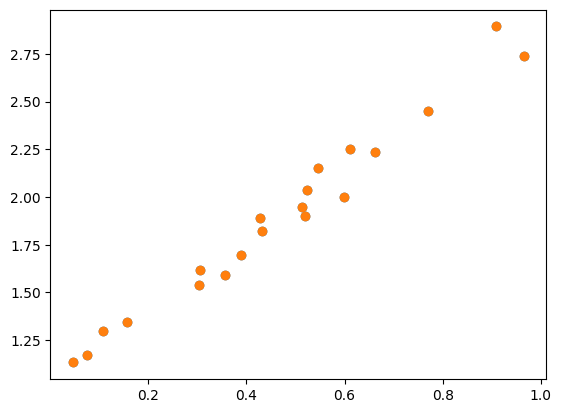

In [ ]:
plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)

## Step 2: build the NN model

In [ ]:
model = nn.Linear(1,1)
model

Linear(in_features=1, out_features=1, bias=True)

## Step 3: define loss function

In [ ]:
loss_fn = nn.MSELoss()

## Step 4: define optimization

In [ ]:
 model.parameters()

<generator object Module.parameters at 0x0000012E26A63920>

In [ ]:
for param in model.namedparameters():
  print(param)

In [ ]:
optimizer = optim.SGD(model.parameters() , lr = 0.01)

## Step 5: train looooop! 🍭

In [ ]:
N = 20
loss_hist = []

for iter in range(N):
    yp = model(x_train)
    loss = loss_fn(yp.squeeze() , y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    loss_hist.append(loss.item())
    print(loss.item())

tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0081, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.0080, grad_fn=<MseLossBackward0>)
tensor(0.00

## Visualizzzzzze 📈

In [ ]:
x_viz = torch.linspace(x_train.min(), x_train.max(), 100).unsqueeze(1)

In [ ]:
y_viz = model(x_viz)

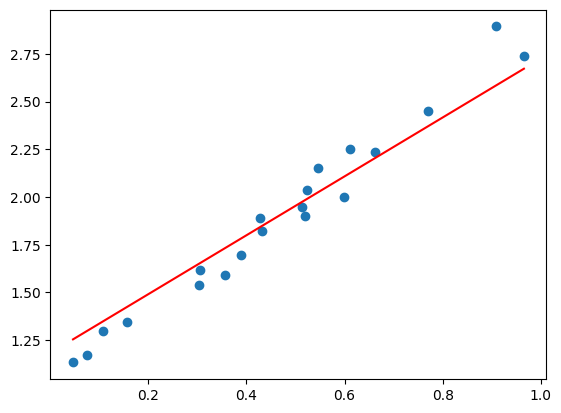

In [ ]:
plt.scatter(x_train, y_train)
plt.plot(x_viz.detach(), y_viz.detach(), 'r')

### Learning curve

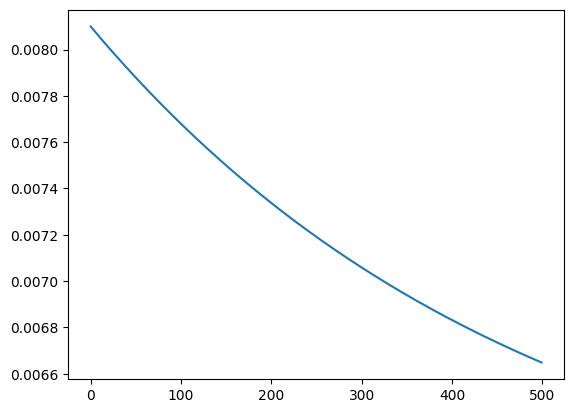

In [ ]:
plt.plot(range(N), loss_hist)

## Step 6: test

In [ ]:
yp = model(x_test)

In [ ]:
F.l1_loss(yp.squeeze(), y_test)

tensor(0.0736, grad_fn=<L1LossBackward0>)

In [ ]:
loss_val = nn.L1Loss()